# Módulo 2 — Detección de Fraude
## Notebook 2: Preprocesamiento de Datos

---

**Objetivo:**  
Preparar el dataset para el modelado, teniendo en cuenta el desbalance extremo (0.17% fraude).  
La estrategia de preprocesamiento aquí es diferente al Módulo 1 — el desbalance es tan severo  
que requiere decisiones metodológicas específicas.

**Input:** `datos/raw/creditcard.csv`  
**Output:** `datos/procesados/fraude_X_train.csv`, `fraude_X_test.csv`, `fraude_y_train.csv`, `fraude_y_test.csv`

---

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
df = pd.read_csv('../../datos/raw/creditcard.csv')

print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Fraude: {df.Class.sum():,} ({df.Class.mean()*100:.4f}%)')
print(f'   Legítimas: {(df.Class==0).sum():,} ({(1-df.Class.mean())*100:.4f}%)')

✅ Dataset cargado: 284,807 filas × 31 columnas
   Fraude: 492 (0.1727%)
   Legítimas: 284,315 (99.8273%)


## 2. Normalización de `Amount` y `Time`

Las variables V1–V28 ya están en escala PCA (media 0, varianza comparable).  
Sin embargo, `Amount` y `Time` tienen escalas muy distintas y necesitan normalizarse.

In [3]:
scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Eliminamos las columnas originales
df = df.drop(columns=['Amount', 'Time'])

print('✅ Amount y Time normalizados')
print(f'   Amount_scaled — media: {df.Amount_scaled.mean():.4f} · std: {df.Amount_scaled.std():.4f}')
print(f'   Time_scaled   — media: {df.Time_scaled.mean():.4f} · std: {df.Time_scaled.std():.4f}')

✅ Amount y Time normalizados
   Amount_scaled — media: -0.0000 · std: 1.0000
   Time_scaled   — media: -0.0000 · std: 1.0000


## 3. Separación de features y variable objetivo

In [4]:
X = df.drop(columns=['Class'])
y = df['Class']

print(f'Features (X): {X.shape[1]} columnas')
print(f'Target  (y): {y.value_counts().to_dict()}')

Features (X): 30 columnas
Target  (y): {0: 284315, 1: 492}


## 4. División train / test

Usamos `stratify=y` para garantizar que el ratio de fraude (0.17%) se mantiene  
tanto en train como en test — fundamental con desbalances tan extremos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} muestras  |  Test: {X_test.shape[0]:,} muestras')
print(f'\nFraude en train: {y_train.sum()} ({y_train.mean()*100:.4f}%)')
print(f'Fraude en test : {y_test.sum()} ({y_test.mean()*100:.4f}%)')

Train: 227,845 muestras  |  Test: 56,962 muestras

Fraude en train: 394 (0.1729%)
Fraude en test : 98 (0.1720%)


## 5. Tratamiento del desbalance — SMOTE

Con un desbalance del 0.17%, aplicar SMOTE puro generaría millones de ejemplos sintéticos.  
La estrategia más eficiente es usar `sampling_strategy` para llevar el fraude al **10% del total**  
— suficiente para que el modelo aprenda, sin inflar artificialmente el dataset.

> En producción bancaria real se suele trabajar con ratios entre 1:10 y 1:20 (fraude:legítimas),  
> no con balanceo perfecto 50/50, para mantener la distribución más cercana a la realidad.

Distribución ANTES de SMOTE:
   Legítimas: 227,451  |  Fraude: 394 (0.1729%)

Distribución DESPUÉS de SMOTE (sampling_strategy=0.1):
   Legítimas: 227,451  |  Fraude: 22745 (9.09%)


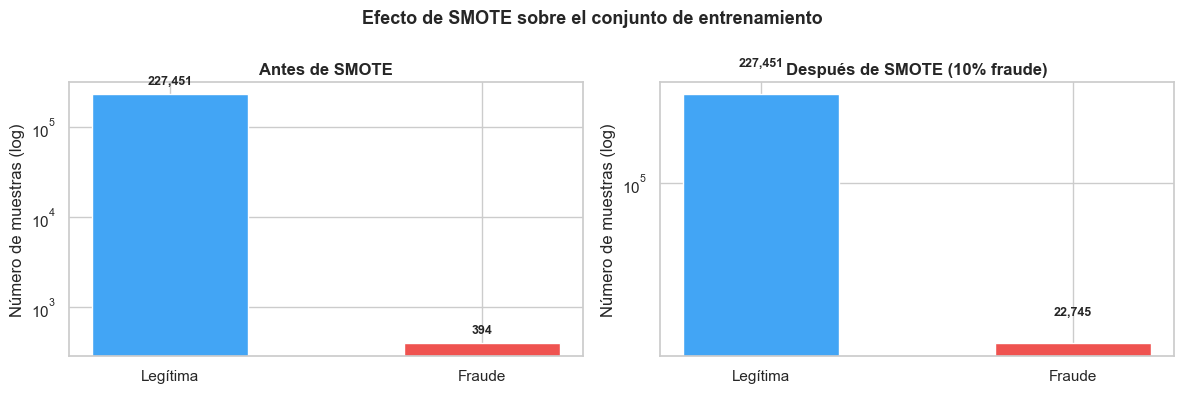

In [6]:
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

fraude_antes  = y_train.sum()
fraude_despues = y_train_res.sum()
total_despues  = len(y_train_res)

print('Distribución ANTES de SMOTE:')
print(f'   Legítimas: {(y_train==0).sum():,}  |  Fraude: {fraude_antes} ({y_train.mean()*100:.4f}%)')
print(f'\nDistribución DESPUÉS de SMOTE (sampling_strategy=0.1):')
print(f'   Legítimas: {(y_train_res==0).sum():,}  |  Fraude: {fraude_despues} ({fraude_despues/total_despues*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, datos, titulo in zip(
    axes,
    [y_train, y_train_res],
    ['Antes de SMOTE', 'Después de SMOTE (10% fraude)']
):
    conteo = pd.Series(dados if isinstance(dados := datos, pd.Series) else datos).value_counts()
    ax.bar(['Legítima', 'Fraude'], [conteo[0], conteo[1]],
           color=['#42A5F5', '#EF5350'], width=0.5)
    ax.set_yscale('log')
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_ylabel('Número de muestras (log)')
    for i, v in enumerate([conteo[0], conteo[1]]):
        ax.text(i, v * 1.3, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Efecto de SMOTE sobre el conjunto de entrenamiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Exportación del dataset procesado

In [7]:
X_train_res_df = pd.DataFrame(X_train_res, columns=X.columns)
X_test_df      = pd.DataFrame(X_test.values, columns=X.columns)

X_train_res_df.to_csv('../../datos/procesados/fraude_X_train.csv', index=False)
X_test_df.to_csv('../../datos/procesados/fraude_X_test.csv', index=False)
pd.Series(y_train_res).to_csv('../../datos/procesados/fraude_y_train.csv', index=False, header=True)
y_test.to_csv('../../datos/procesados/fraude_y_test.csv', index=False, header=True)

print('✅ Archivos exportados a datos/procesados/:')
print(f'   · fraude_X_train.csv — {X_train_res_df.shape[0]:,} muestras × {X_train_res_df.shape[1]} columnas')
print(f'   · fraude_X_test.csv  — {X_test_df.shape[0]:,} muestras × {X_test_df.shape[1]} columnas')
print(f'   · fraude_y_train.csv')
print(f'   · fraude_y_test.csv')

✅ Archivos exportados a datos/procesados/:
   · fraude_X_train.csv — 250,196 muestras × 30 columnas
   · fraude_X_test.csv  — 56,962 muestras × 30 columnas
   · fraude_y_train.csv
   · fraude_y_test.csv


## 7. Resumen del preprocesamiento

---

| Paso | Técnica | Resultado |
|------|---------|----------|
| Normalización | StandardScaler sobre `Amount` y `Time` | Variables en escala comparable a V1–V28 |
| División train/test | 80% / 20% estratificado | Ratio de fraude preservado en ambos conjuntos |
| Balanceo de clases | SMOTE con `sampling_strategy=0.1` | Fraude elevado al 10% del train |

**💡 Decisión metodológica clave:** En lugar de balancear al 50/50, llevamos el fraude al 10%.  
Un balanceo perfecto distorsionaría demasiado la distribución real y produciría un modelo  
que funcionaría bien en el notebook pero mal en producción. El 10% es un compromiso  
entre dar suficiente señal al modelo y mantener una distribución realista.

